<a href="https://colab.research.google.com/github/Bubukisapisa/ML_education/blob/main/HW_%D0%92%D1%81%D1%82%D1%83%D0%BF_%D0%B4%D0%BE_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%B8%D1%85_%D0%BC%D0%B5%D1%80%D0%B5%D0%B6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [3]:
inputs_t = torch.from_numpy(inputs)
targets_t = torch.from_numpy(targets)

display(inputs_t, targets_t)

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])

tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])

2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [4]:
torch.random.manual_seed(1)

In [5]:
w = torch.randn(3, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
w, b

(tensor([[0.6614],
         [0.2669],
         [0.0617]], requires_grad=True),
 tensor([0.6213], requires_grad=True))

3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [6]:
def model (x, w, b):
  lin_tr = x @ w + b
  e_x = torch.exp(-lin_tr)
  sigmoid = 1/(1 + e_x)
  return sigmoid

In [7]:
preds = model(inputs_t, w, b)

Модель вийшла дуже невпевненою, проставляє виключно 0, імовірно тому що початкові ваги і зміщення мають від'ємні значення і сильно занижують цим прогноз

4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [8]:
def binary_cross_entropy(y, y_pr):
  eps = 1e-7
  y_pr = torch.clamp(y_pr, eps, 1 - eps) # це мені підказав клод бо loss просто не обчислює через 0 в передбаченнях
  loss_per_sample = - (y * torch.log(y_pr) + (1 - y)* torch.log(1 - y_pr))

  return torch.mean(loss_per_sample)

loss = binary_cross_entropy(targets_t, preds)
loss

tensor(6.3770, grad_fn=<MeanBackward0>)

5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [9]:
loss.backward()

print(w)
print(w.grad)

print(b)
print(b.grad)

tensor([[0.6614],
        [0.2669],
        [0.0617]], requires_grad=True)
tensor([[0.],
        [0.],
        [0.]])
tensor([0.6213], requires_grad=True)
tensor([0.])


Можливо похідна немає куди далі рухатись?

**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [10]:
torch.random.manual_seed(1)
w = torch.randn(1, 3, requires_grad=True)  # Листовий тензор
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000

In [11]:
w, b

(tensor([[6.6135e-04, 2.6692e-04, 6.1677e-05]], requires_grad=True),
 tensor([0.0006], requires_grad=True))

6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [12]:
torch.random.manual_seed(1)
w = torch.randn(3, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
w.data = w.data / 1000
b.data = b.data / 1000
x = inputs_t
y = targets_t

In [13]:
lr = 1e-3
num_epochs = 1000
loss_history = []

for epoc in range(num_epochs):
  y_pr = model(x,w,b)

  loss = binary_cross_entropy(y, y_pr)
  loss_history.append(loss.item())
  loss.backward()

  with torch.no_grad():
    w -= w.grad * lr
    b -= b.grad * lr
    w.grad.zero_()
    b.grad.zero_()

  if (epoc + 1) % 100 == 0:
        print(f"Епоха [{epoc+1}/{num_epochs}], Loss: {loss.item():.4f}")

Епоха [100/1000], Loss: 0.1979
Епоха [200/1000], Loss: 0.1624
Епоха [300/1000], Loss: 0.1382
Епоха [400/1000], Loss: 0.1198
Епоха [500/1000], Loss: 0.1054
Епоха [600/1000], Loss: 0.0937
Епоха [700/1000], Loss: 0.0842
Епоха [800/1000], Loss: 0.0763
Епоха [900/1000], Loss: 0.0697
Епоха [1000/1000], Loss: 0.0640


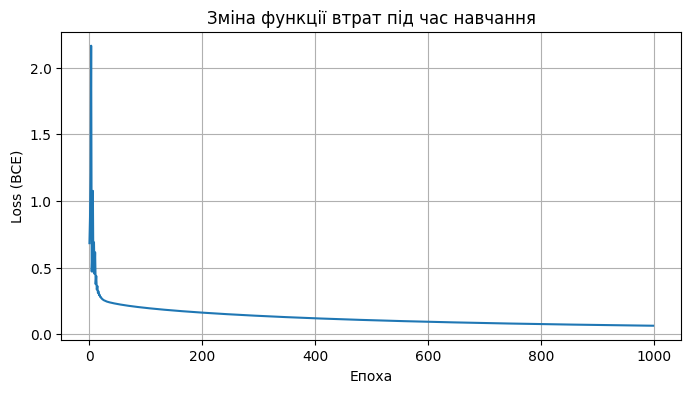


Фінальні передбачення (ймовірності):
tensor([[1.6794e-01],
        [8.7483e-01],
        [9.9771e-01],
        [2.3266e-07],
        [9.9999e-01]])

Передбачені класи (поріг 0.5):
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Справжні таргети:
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Точність моделі: 100.0%


In [14]:
#це ідея клода - візуалізувати, вона хороша тому забрав собі
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Епоха")
plt.ylabel("Loss (BCE)")
plt.title("Зміна функції втрат під час навчання")
plt.grid(True)
plt.show()

# Фінальні передбачення
final_preds = model(x,w,b)
print("\nФінальні передбачення (ймовірності):")
print(final_preds.detach())
print("\nПередбачені класи (поріг 0.5):")
print((final_preds >= 0.5).float().detach())
print("\nСправжні таргети:")
print(targets_t)

# Точність
accuracy = ((final_preds >= 0.5).float() == targets_t).float().mean()
print(f"\nТочність моделі: {accuracy.item() * 100:.1f}%")

**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [15]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [16]:
x = torch.from_numpy(inputs)
y = torch.from_numpy(targets)

train_ds = TensorDataset(x, y)

print("Перші 3 елементи датасету:")
for i in range(3):
    print(f"Елемент {i}: inputs={train_ds[i][0]}, target={train_ds[i][1]}")

Перші 3 елементи датасету:
Елемент 0: inputs=tensor([73., 67., 43.]), target=tensor([0.])
Елемент 1: inputs=tensor([91., 88., 64.]), target=tensor([1.])
Елемент 2: inputs=tensor([ 87., 134.,  58.]), target=tensor([1.])


8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [17]:
batch_size=5
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

first_iter = next(iter(train_dl))

print(first_iter[0])
print(first_iter[1])

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.],
        [102.,  43.,  37.]])
tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [29]:
class LogReg(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear = nn.Linear(3,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.linear(x)
    x = self.sigmoid(x)

    return x

model = LogReg()

print("Архітектура моделі:")
print(model)
print("\nПараметри моделі:")
for name, param in model.named_parameters():
    print(f"  {name}: shape={param.shape}, values={param.data}")

Архітектура моделі:
LogReg(
  (linear): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Параметри моделі:
  linear.weight: shape=torch.Size([1, 3]), values=tensor([[-0.5200,  0.5167,  0.0391]])
  linear.bias: shape=torch.Size([1]), values=tensor([-0.2846])


10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [30]:
opt = torch.optim.SGD(model.parameters(), 1e-3)
loss_fn = torch.nn.functional.binary_cross_entropy

init_pred = model(x)
init_loss = loss_fn(init_pred, y)
print("Початкові втрати (до навчання):", init_loss.item())

Початкові втрати (до навчання): 0.1322154849767685


ні модель зовсм не навчилась помилка величезна (має бути наближена до 0).

11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

In [31]:
def fit_return_loss(num_epochs, model, loss_fn, opt, train_dl):
    losses = []
    for epoch in range(num_epochs):
        # Ініціалізуємо акумулятор для втрат
        total_loss = 0

        for xb, yb in train_dl:
            # Генеруємо передбачення
            pred = model(xb)

            # Обчислюємо втрати
            loss = loss_fn(pred, yb)

            # Виконуємо градієнтний спуск
            loss.backward()
            opt.step()
            opt.zero_grad()

            # Накопичуємо втрати
            total_loss += loss.item()

        # Обчислюємо середні втрати для епохи
        avg_loss = total_loss / len(train_dl)
        losses.append(avg_loss)

        # Виводимо підсумок епохи
        if (epoch + 1) % 10 == 0:
          print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    return losses

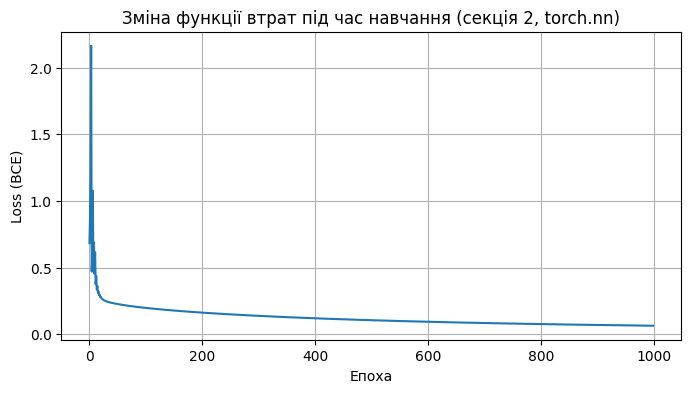

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Епоха")
plt.ylabel("Loss (BCE)")
plt.title("Зміна функції втрат під час навчання (секція 2, torch.nn)")
plt.grid(True)
plt.show()

In [32]:
fit_return_loss(1000, model, loss_fn, opt, train_dl)

Epoch [10/1000], Loss: 0.1366
Epoch [20/1000], Loss: 0.1452
Epoch [30/1000], Loss: 0.0874
Epoch [40/1000], Loss: 0.1375
Epoch [50/1000], Loss: 0.0958
Epoch [60/1000], Loss: 0.3963
Epoch [70/1000], Loss: 0.1631
Epoch [80/1000], Loss: 0.0759
Epoch [90/1000], Loss: 0.0790
Epoch [100/1000], Loss: 0.1010
Epoch [110/1000], Loss: 0.0930
Epoch [120/1000], Loss: 0.0676
Epoch [130/1000], Loss: 0.0719
Epoch [140/1000], Loss: 0.0735
Epoch [150/1000], Loss: 0.0637
Epoch [160/1000], Loss: 0.0653
Epoch [170/1000], Loss: 0.0648
Epoch [180/1000], Loss: 0.0631
Epoch [190/1000], Loss: 0.0605
Epoch [200/1000], Loss: 0.0641
Epoch [210/1000], Loss: 0.1011
Epoch [220/1000], Loss: 0.0613
Epoch [230/1000], Loss: 0.0524
Epoch [240/1000], Loss: 0.0569
Epoch [250/1000], Loss: 0.0479
Epoch [260/1000], Loss: 0.0465
Epoch [270/1000], Loss: 0.0468
Epoch [280/1000], Loss: 0.0682
Epoch [290/1000], Loss: 0.0575
Epoch [300/1000], Loss: 0.0499
Epoch [310/1000], Loss: 0.0404
Epoch [320/1000], Loss: 0.0464
Epoch [330/1000],

[0.13047758986552557,
 0.24803536726782718,
 0.19067514439445266,
 0.13672747711340585,
 0.11492111782232921,
 0.11401129265626271,
 0.1054681067665418,
 0.11248246828715007,
 0.10611451168855031,
 0.13661040427784124,
 0.1506730392575264,
 0.09391918281714122,
 0.11803288012742996,
 0.13341749381894866,
 0.19469824681679407,
 0.10491558040181796,
 0.09844601899385452,
 0.09602852414051692,
 0.1284190540512403,
 0.14521953277289867,
 0.10647601485252996,
 0.10601103057463963,
 0.15862194200356802,
 0.15810961152116457,
 0.21161628250653544,
 0.11578389257192612,
 0.09598556657638406,
 0.09548740337292354,
 0.08766761422157288,
 0.08741971850396892,
 0.1401046117146868,
 0.12188488245010376,
 0.08641167481741895,
 0.08611097186803818,
 0.10526259119311969,
 0.10492578893899918,
 0.08523568759361903,
 0.09716610858837764,
 0.09000006814797719,
 0.13747691114743552,
 0.11120194693406422,
 0.10187093168497086,
 0.08501038203636806,
 0.08944115539391835,
 0.0858313577870528,
 0.088408744583

In [36]:
print("\nФінальні передбачення (ймовірності):")
print(final_preds.detach())
print("\nПередбачені класи (поріг 0.5):")
print((final_preds >= 0.5).float().detach())
print("\nСправжні таргети:")
print(y)


Фінальні передбачення (ймовірності):
tensor([[4.8636e-02],
        [9.6134e-01],
        [1.0000e+00],
        [2.8140e-18],
        [1.0000e+00],
        [4.8636e-02],
        [9.6134e-01],
        [1.0000e+00],
        [2.8140e-18],
        [1.0000e+00],
        [4.8636e-02],
        [9.6134e-01],
        [1.0000e+00],
        [2.8140e-18],
        [1.0000e+00]])

Передбачені класи (поріг 0.5):
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Справжні таргети:
tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])


In [34]:
final_preds = model(x)
predicted_classes = (final_preds >= 0.5).float()
accuracy = (predicted_classes == y).float().mean()
print(f"\nТочність моделі: {accuracy.item() * 100:.1f}%")


Точність моделі: 100.0%
